In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload

import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import inspect
import time
import os

sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

In [2]:
model_excludes = ['CIBerNew', 'CIBerOld']
model_rename = {'CIBerFS': 'CIBer'}
scores = {}

for f in os.listdir():
    fname, fext =  os.path.splitext(f)
    if fext == '.csv':
        scores[fname] = pd.read_csv(f, index_col=0, header=[0, 1])

scores = pd.concat(scores, names=['dataset'])
scores = scores.drop(columns=model_excludes, level='model')
scores = scores.rename(model_rename, level='model', axis=1)
scores

model                           CIBer                            NB            \
stat                        precision    recall  f1-score precision    recall   
dataset                iter                                                     
Amazon_Dissatisfied    0     0.715590  0.698584  0.706354  0.652876  0.617715   
                       1     0.747675  0.727183  0.736485  0.677224  0.627158   
                       2     0.737254  0.725973  0.731311  0.680582  0.626719   
                       3     0.736113  0.720356  0.727645  0.670957  0.623185   
                       4     0.724996  0.703134  0.712878  0.666827  0.621898   
...                               ...       ...       ...       ...       ...   
DataCo_Delivery Status 295   0.587557  0.555561  0.556196  0.578325  0.534958   
                       296   0.678335  0.611289  0.610751  0.597892  0.546444   
                       297   0.572577  0.549323  0.537108  0.580878  0.543533   
                       298   0.616086  0.585844  0.576830  0.601748  0.559474   
                       299   0.597443  0.568162  0.565915  0.584531  0.564717   

model                                       SVM                      Logistic  \
stat                         f1-score precision    recall  f1-score precision   
dataset                iter                                                     
Amazon_Dissatisfied    0     0.630131  0.676103  0.584417  0.599648  0.687079   
                       1     0.643084  0.709493  0.589997  0.606222  0.712730   
                       2     0.643401  0.694359  0.583971  0.598129  0.706070   
                       3     0.638422  0.694923  0.587694  0.603078  0.699501   
                       4     0.636614  0.691781  0.589433  0.605686  0.704688   
...                               ...       ...       ...       ...       ...   
DataCo_Delivery Status 295   0.539374  0.596681  0.584920  0.582022  0.594920   
                       296   0.557442  0.672510  0.638887  0.638381  0.678879   
                       297   0.547479  0.578012  0.579214  0.573652  0.592888   
                       298   0.561090  0.622527  0.604627  0.601870  0.628727   
                       299   0.566477  0.612124  0.602868  0.601514  0.618412   

model                        ...       LDA   LDA_PCA                      \
stat                         ...  f1-score precision    recall  f1-score   
dataset                iter  ...                                           
Amazon_Dissatisfied    0     ...  0.632948  0.673893  0.595377  0.612213   
                       1     ...  0.635012  0.694914  0.594933  0.611785   
                       2     ...  0.632035  0.691999  0.592224  0.608442   
                       3     ...  0.629902  0.681820  0.587282  0.602080   
                       4     ...  0.635033  0.692123  0.598621  0.616656   
...                          ...       ...       ...       ...       ...   
DataCo_Delivery Status 295   ...  0.378435  0.608930  0.593739  0.590937   
                       296   ...  0.374430  0.669036  0.641086  0.640906   
                       297   ...  0.340182  0.587288  0.586523  0.583824   
                       298   ...  0.350390  0.637027  0.619790  0.618830   
                       299   ...  0.341392  0.612756  0.605326  0.602630   

model                       Decision_Tree                           KNN  \
stat                            precision    recall  f1-score precision   
dataset                iter                                               
Amazon_Dissatisfied    0         0.764034  0.763504  0.763768  0.708412   
                       1         0.769489  0.765415  0.767419  0.720877   
                       2         0.779333  0.770795  0.774926  0.730669   
                       3         0.770361  0.762668  0.766398  0.717808   
                       4         0.756987  0.759669  0.758313  0.699333   
...                                   ...       ...       ...    

In [3]:
model_rank = scores.groupby('stat', axis=1).rank(ascending=False, method='min')
model_rank_avg = model_rank.groupby('dataset').mean()

/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_13021/1171969301.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  model_rank = scores.groupby('stat', axis=1).rank(ascending=False, method='min')


/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_13021/3449267281.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for stat, r in model_rank_avg.groupby('stat', axis=1, sort=False):


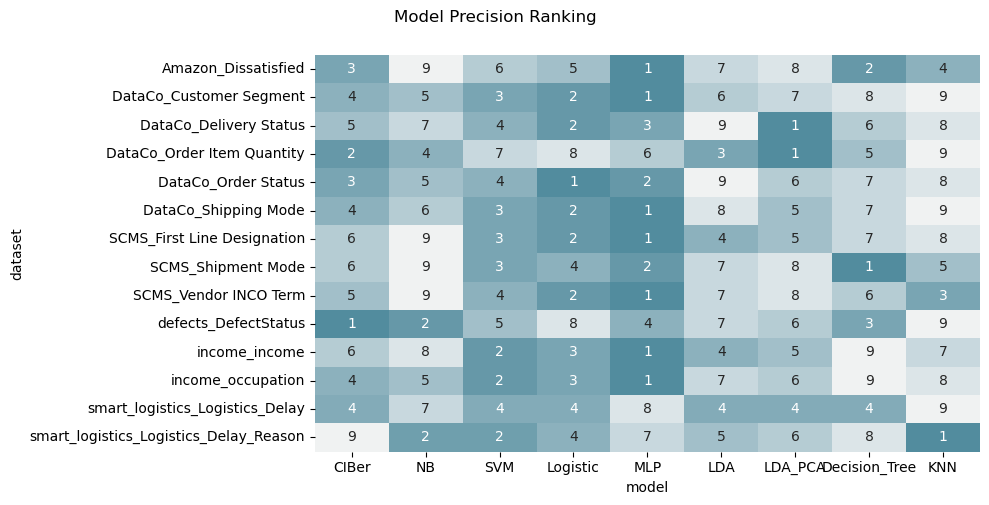

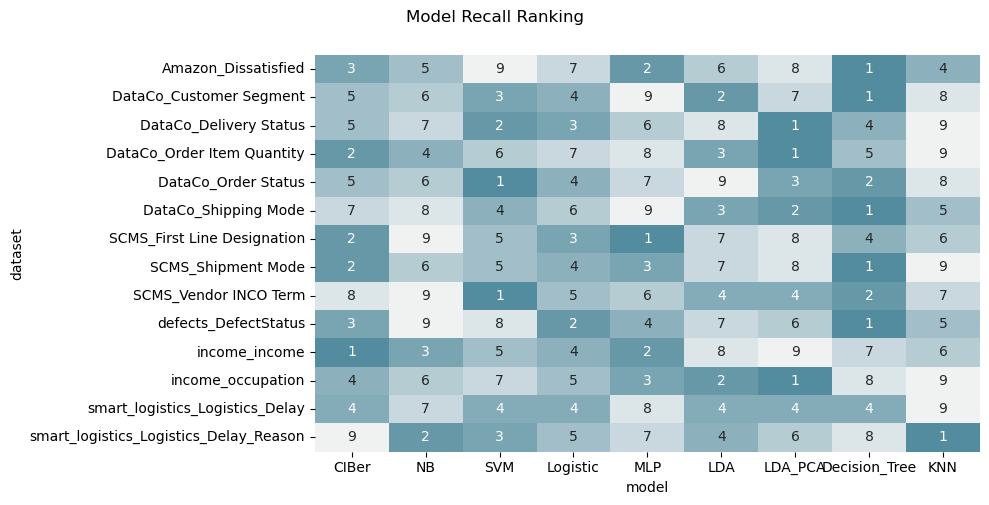

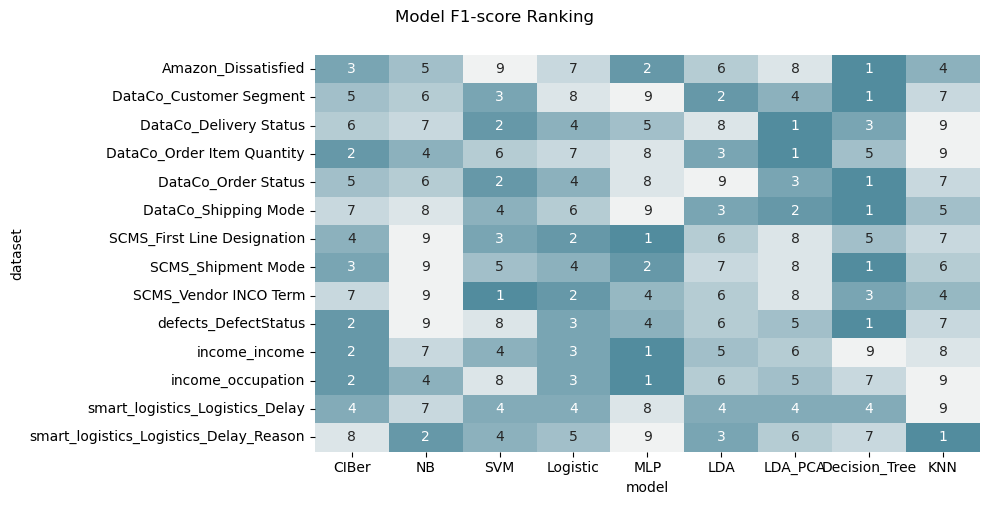

In [4]:
for stat, r in model_rank_avg.groupby('stat', axis=1, sort=False):
    r = r.xs(stat, level='stat', axis=1)
    r = r.rank(axis=1)
    n_model = r.shape[1]
    pplot.heatmap(n_model - r, annot=r, center=0, vmax=n_model,
                 title=f'Model {stat.capitalize()} Ranking', fmt='.0f')

/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_13021/422344992.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for stat, s in scores_median.groupby('stat', axis=1, sort=False):


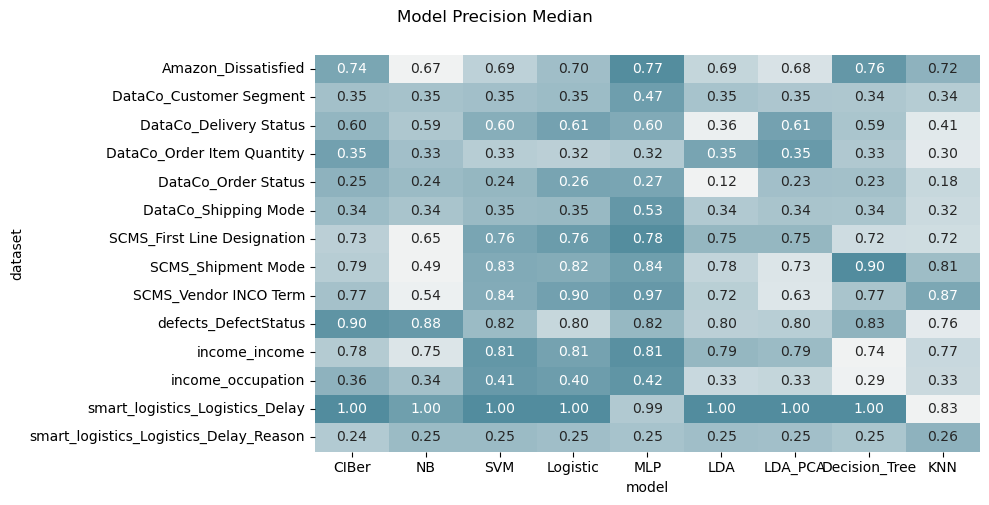

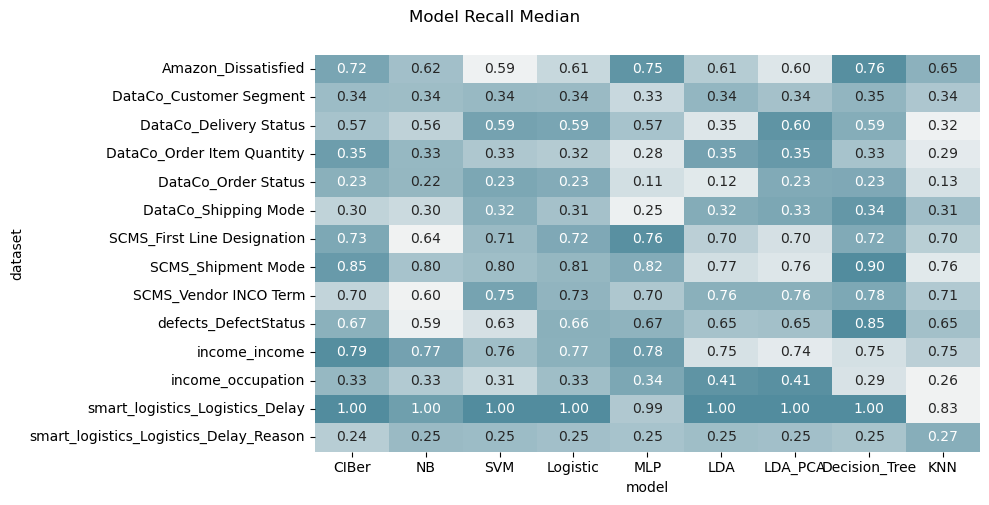

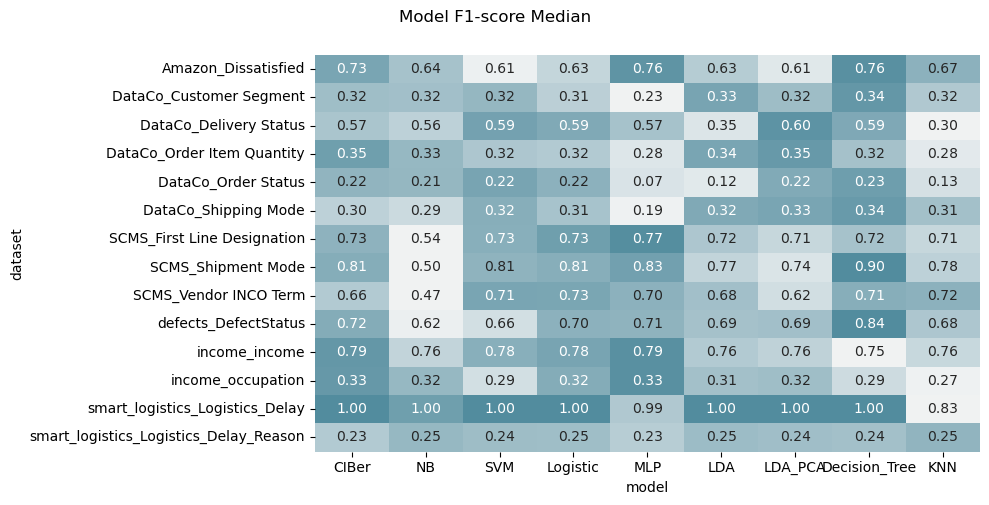

In [5]:
scores_median = scores.groupby('dataset').median()

for stat, s in scores_median.groupby('stat', axis=1, sort=False):
    s = s.xs(stat, level='stat', axis=1)
    r = model_rank_avg.xs(stat, level='stat', axis=1)
    pplot.heatmap(n_model - r, annot=s, center=0, vmax=n_model, 
                 title=f'Model {stat.capitalize()} Median', fmt='.2f')